## Описание датасета

В работе используется датасет CRM Sales Opportunities, содержащий информацию о сделках отдела продаж.

Основные поля:
- opportunity_id — идентификатор сделки
- sales_agent — менеджер по продажам
- product — продукт
- account — клиент
- deal_stage — стадия сделки
- engage_date — дата начала взаимодействия
- close_date — дата закрытия сделки
- close_value — сумма сделки

In [1]:
# ============================================================
# ВКР: Business Intelligence для руководителя, дашборд решений на уровне отдела продаж
# Этап: предобработка и EDA датасета CRM Sales Opportunities
# ============================================================

# ----------------------------
# 1. Импорт библиотек
# ----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# настройки отображения
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 1200)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


In [2]:
import zipfile
from pathlib import Path

zip_path = Path("archive.zip")   
extract_path = Path("data")

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Архив распакован")

Архив распакован


In [3]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("data") 

accounts = pd.read_csv(DATA_DIR / "accounts.csv")
products = pd.read_csv(DATA_DIR / "products.csv")
sales_pipeline = pd.read_csv(DATA_DIR / "sales_pipeline.csv")
sales_teams = pd.read_csv(DATA_DIR / "sales_teams.csv")
data_dictionary = pd.read_csv(DATA_DIR / "data_dictionary.csv")

In [4]:
print(sales_pipeline.head())
print(sales_pipeline.columns)

  opportunity_id      sales_agent         product  account deal_stage engage_date  close_date  close_value
0       1C1I7A6R      Moses Frase  GTX Plus Basic  Cancity        Won  2016-10-20  2017-03-01       1054.0
1       Z063OYW0  Darcel Schlecht          GTXPro    Isdom        Won  2016-10-25  2017-03-11       4514.0
2       EC4QE1BX  Darcel Schlecht      MG Special  Cancity        Won  2016-10-25  2017-03-07         50.0
3       MV1LWRNH      Moses Frase       GTX Basic  Codehow        Won  2016-10-25  2017-03-09        588.0
4       PE84CX4O        Zane Levy       GTX Basic   Hatfan        Won  2016-10-25  2017-03-02        517.0
Index(['opportunity_id', 'sales_agent', 'product', 'account', 'deal_stage', 'engage_date', 'close_date', 'close_value'], dtype='object')


In [5]:
# анализ пропусков
missing = sales_pipeline.isnull().sum()

missing_df = pd.DataFrame({
    "column": missing.index,
    "missing_count": missing.values,
    "missing_percent": (missing.values / len(sales_pipeline) * 100).round(2)
})

missing_df

,column,missing_count,missing_percent
0,opportunity_id,0,0.00
1,sales_agent,0,0.00
2,product,0,0.00
3,account,1425,16.19
4,deal_stage,0,0.00
5,engage_date,500,5.68
6,close_date,2089,23.74
7,close_value,2089,23.74


Пропуски в полях, связанных с закрытием сделки, не устранялись, так как они соответствуют незавершённым сделкам. Для корректного анализа показатели выручки и длительности рассчитывались только по завершённым сделкам.

In [6]:
duplicates_count = sales_pipeline.duplicated().sum()
print("Количество дубликатов:", duplicates_count)

Количество дубликатов: 0


Анализ дублирующихся записей показал отсутствие дубликатов в датасете, что подтверждает корректность структуры данных и исключает необходимость дополнительной очистки.

## Предобработка данных

На данном этапе были выполнены следующие операции:
- преобразование типов данных;
- анализ и обработка пропусков;
- проверка дубликатов;
- создание новых признаков (успешность сделки, длительность сделки, временные признаки).

In [17]:
# ----------------------------
# Предобработка данных
# ----------------------------

# 1. Преобразование типов
sales_pipeline["engage_date"] = pd.to_datetime(sales_pipeline["engage_date"])
sales_pipeline["close_date"] = pd.to_datetime(sales_pipeline["close_date"])
sales_pipeline["close_value"] = pd.to_numeric(sales_pipeline["close_value"], errors="coerce")

# 2. Создание новых признаков

# успешная сделка
sales_pipeline["is_won"] = (sales_pipeline["deal_stage"] == "Won").astype(int)

# месяц
sales_pipeline["month"] = sales_pipeline["engage_date"].dt.to_period("M").astype(str)

In [18]:
sales_pipeline["deal_duration"] = (
    sales_pipeline["close_date"] - sales_pipeline["engage_date"]
).dt.days

# убираем отрицательные значения (если вдруг есть)
sales_pipeline.loc[sales_pipeline["deal_duration"] < 0, "deal_duration"] = None

## Разведочный анализ данных (EDA)

Целью данного этапа является изучение структуры и особенностей датасета, выявление закономерностей, а также определение ключевых метрик для построения BI-дашборда.

В рамках разведочного анализа данных решаются следующие задачи:
- анализ динамики количества сделок во времени;
- оценка структуры воронки продаж (распределение сделок по стадиям);
- анализ эффективности сотрудников отдела продаж;
- оценка показателей результативности (выручка, win rate, средний чек);
- анализ длительности сделок.

Особое внимание уделяется анализу сотрудников, так как в рамках данной работы руководитель принимает управленческие решения именно на уровне команды.

In [9]:
total_deals = len(sales_pipeline)
won_deals = sales_pipeline["is_won"].sum()
win_rate = won_deals / total_deals

print("Всего сделок:", total_deals)
print("Успешных:", won_deals)
print("Win rate:", round(win_rate * 100, 2), "%")

Всего сделок: 8800
Успешных: 4238
Win rate: 48.16 %


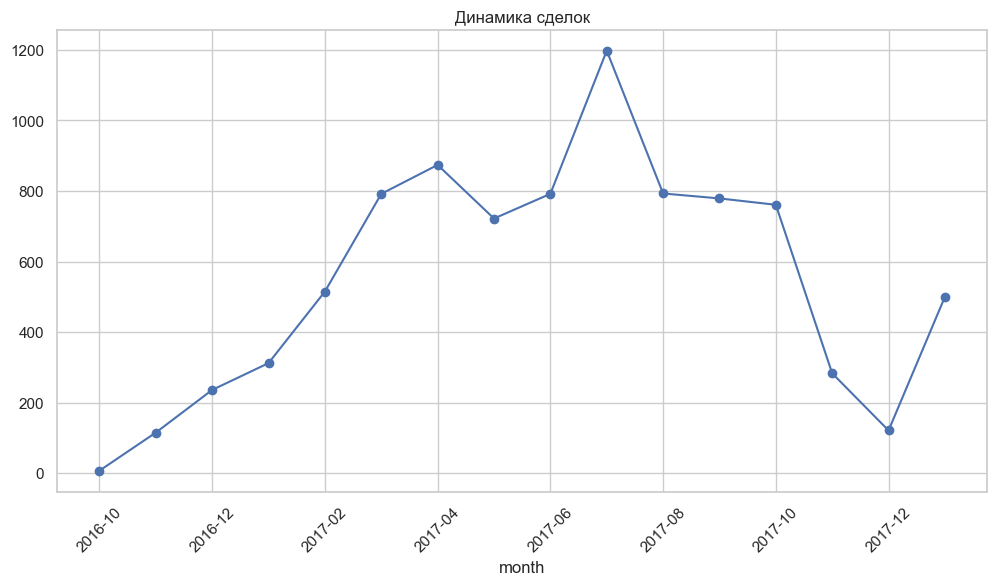

In [10]:
deals_by_month = sales_pipeline.groupby("month").size()

deals_by_month.plot(kind="line", marker="o")
plt.title("Динамика сделок")
plt.xticks(rotation=45)
plt.show()

Вывод:
Наблюдается изменение количества сделок во времени, что может свидетельствовать о сезонных колебаниях активности отдела продаж.
В отдельные периоды наблюдается рост количества сделок, что может быть связано с увеличением спроса или более активной работой команды.

In [11]:
agent_kpi = sales_pipeline.groupby("sales_agent").agg(
    deals_count=("opportunity_id", "count"),
    won_deals=("is_won", "sum"),
    revenue=("close_value", "sum"),
    avg_check=("close_value", "mean"),
    avg_duration=("deal_duration", "mean")
).reset_index()

agent_kpi["win_rate"] = agent_kpi["won_deals"] / agent_kpi["deals_count"]

agent_kpi = agent_kpi.sort_values("revenue", ascending=False)

agent_kpi.head()

,sales_agent,deals_count,won_deals,revenue,avg_check,avg_duration,win_rate
6,Darcel Schlecht,747,349,1153214.0,2085.377939,45.842676,0.467202
26,Vicki Laflamme,451,221,478396.0,1378.662824,46.556196,0.490022
15,Kary Hendrixson,438,209,454298.0,1356.113433,49.850746,0.477169
2,Cassey Cress,346,163,450489.0,1726.011494,45.961686,0.471098
7,Donn Cantrell,275,158,445860.0,1621.309091,48.930909,0.574545


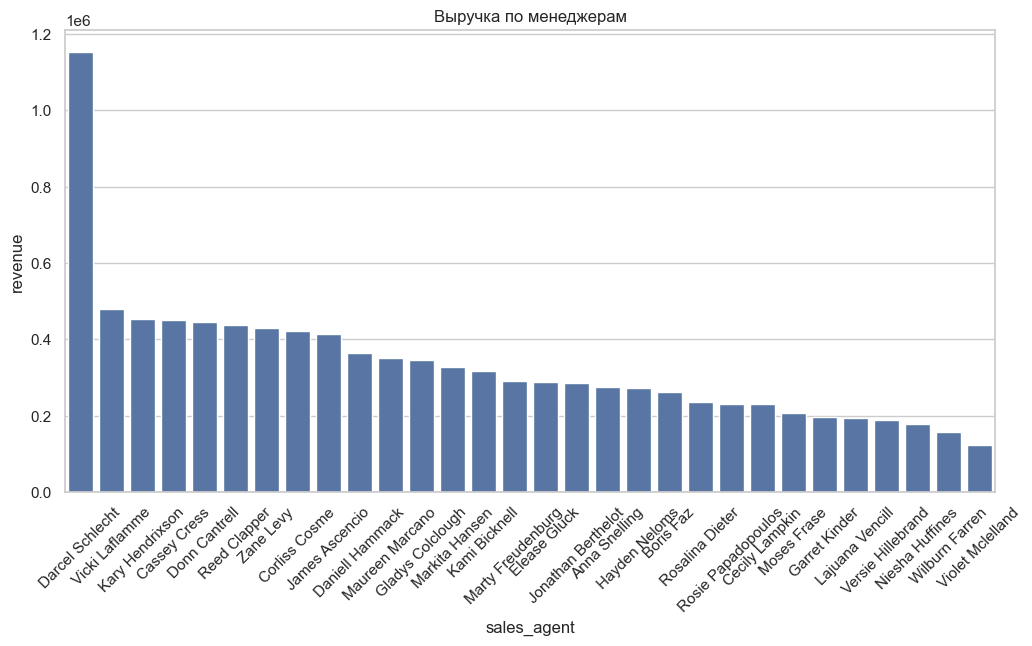

In [12]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(data=agent_kpi, x="sales_agent", y="revenue")
plt.xticks(rotation=45)
plt.title("Выручка по менеджерам")
plt.show()

Вывод:

Выручка распределена между менеджерами неравномерно. Наблюдается сотрудник, значительно превосходящий остальных по объёму продаж.

Дополнительная проверка показала, что данный результат не является следствием аномальных значений или единичных крупных сделок.
Установлено, что данный сотрудник имеет наибольшее количество сделок, а также формирует высокий совокупный объём выручки.

Таким образом, выявленный разрыв обусловлен реальными различиями в эффективности работы сотрудников, что является важным фактором для управленческого анализа.


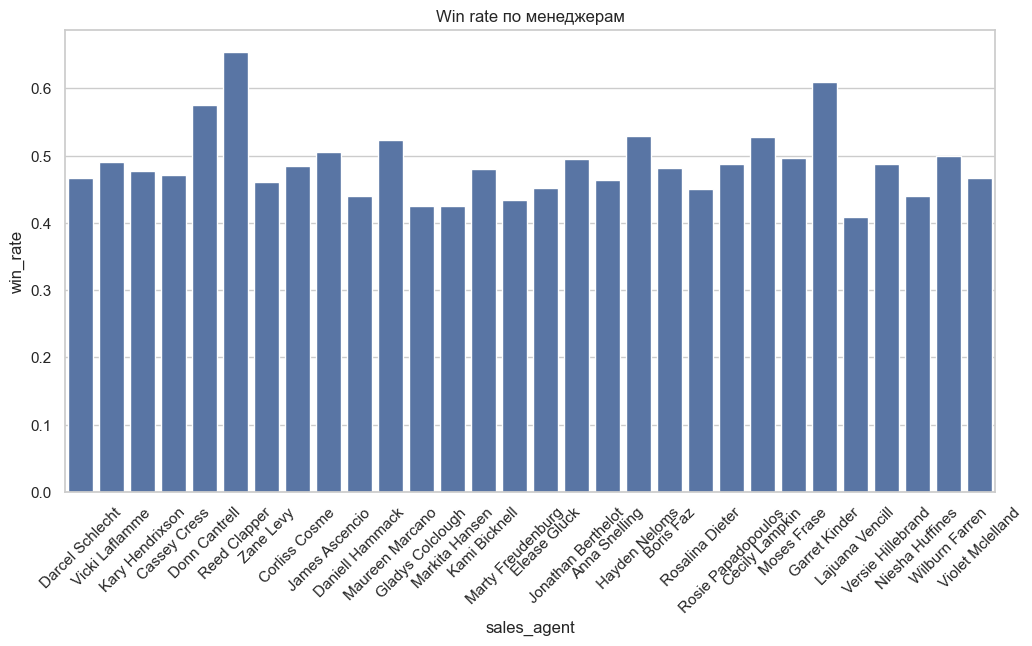

In [13]:
plt.figure(figsize=(12,6))
sns.barplot(data=agent_kpi, x="sales_agent", y="win_rate")
plt.xticks(rotation=45)
plt.title("Win rate по менеджерам")
plt.show()

Вывод:
Показатель win rate различается между сотрудниками, что указывает на неодинаковую эффективность закрытия сделок.
Это может свидетельствовать о различиях в навыках ведения переговоров или качестве работы с клиентами.


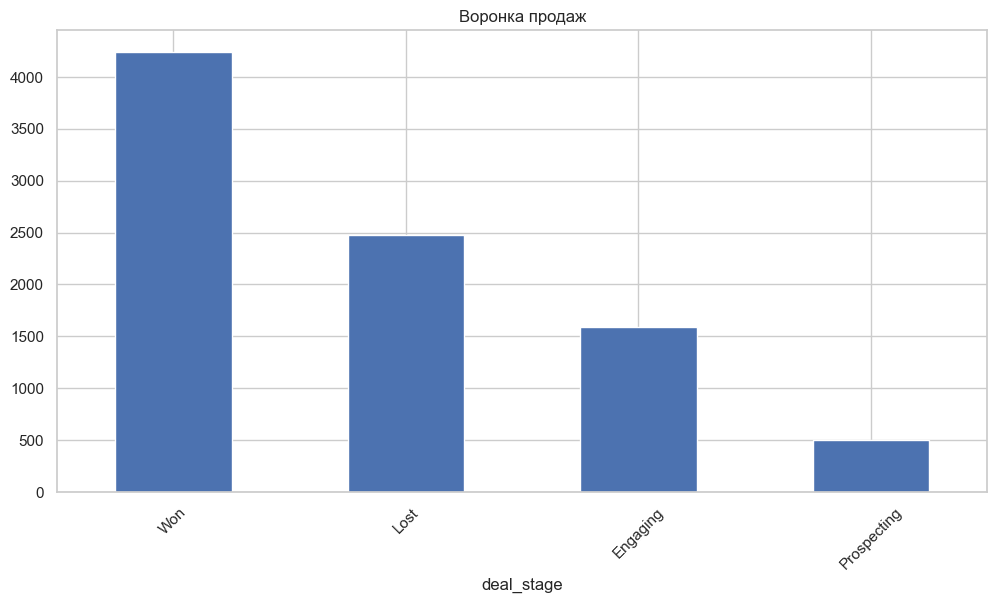

In [14]:
stage_counts = sales_pipeline["deal_stage"].value_counts()

stage_counts.plot(kind="bar")
plt.title("Воронка продаж")
plt.xticks(rotation=45)
plt.show()

Вывод:
Распределение сделок по стадиям показывает, что значительная часть сделок не доходит до успешного завершения.
Это указывает на возможные потери на этапах воронки продаж и необходимость анализа причин отказов.


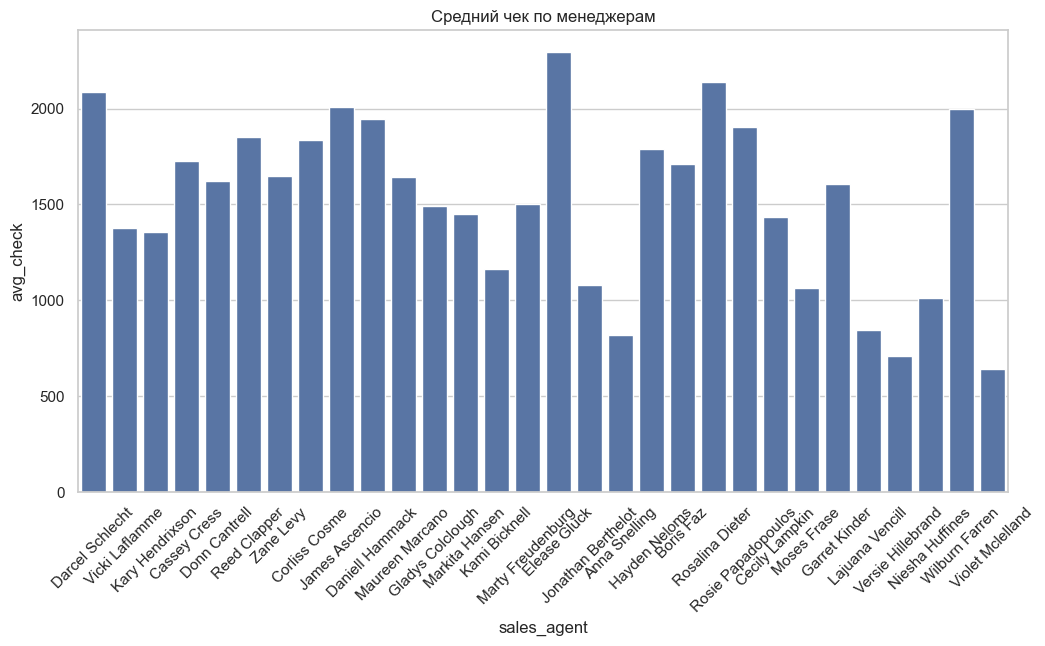

In [15]:
plt.figure(figsize=(12,6))
sns.barplot(data=agent_kpi, x="sales_agent", y="avg_check")
plt.xticks(rotation=45)
plt.title("Средний чек по менеджерам")
plt.show()

Вывод:
Средний чек по менеджерам также различается, что может указывать на специализацию сотрудников: одни работают с крупными сделками, другие — с более мелкими.
Это важно учитывать при оценке эффективности сотрудников.

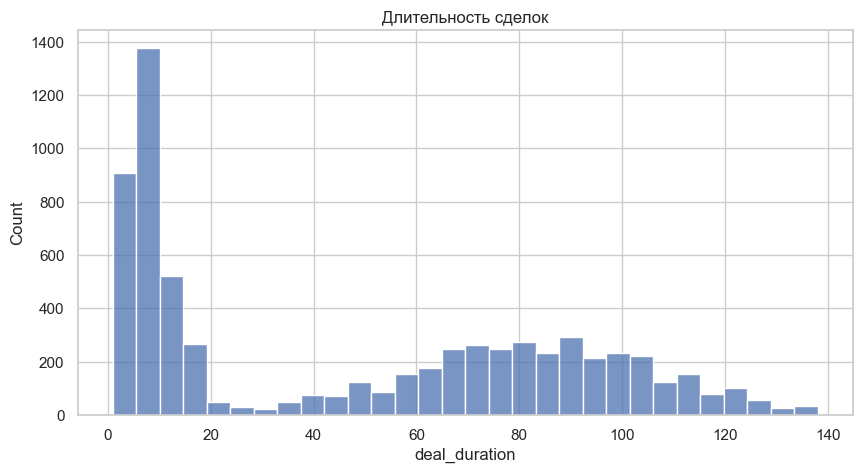

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(sales_pipeline["deal_duration"], bins=30)
plt.title("Длительность сделок")
plt.show()

Вывод:
Длительность сделок варьируется, что может указывать на наличие различных типов продаж: быстрых и более сложных, требующих длительного времени.
Это важно учитывать при планировании работы и прогнозировании результатов.


Итоговые выводы:

В ходе проведённого анализа данных было установлено, что деятельность отдела продаж характеризуется рядом значимых особенностей.

Во-первых, наблюдается неравномерная динамика количества сделок во времени, что может быть связано с сезонными факторами или изменением активности команды.

Во-вторых, доля успешно завершённых сделок составляет около 48%, что указывает на наличие потерь на различных этапах воронки продаж и необходимость их дополнительного анализа.

В-третьих, выявлены различия в эффективности сотрудников: наблюдается существенный разброс по выручке, количеству сделок и показателю win rate.
Дополнительная проверка показала, что лидеры по выручке достигают результатов не за счёт выбросов, а за счёт большего количества и/или более качественных сделок.

В-четвёртых, установлено, что сделки различаются по длительности, что позволяет выделить различные типы продаж (быстрые и длительные), требующие разных подходов к управлению.

Таким образом, результаты анализа подтверждают необходимость разработки BI-дашборда, ориентированного на мониторинг эффективности сотрудников, анализ воронки продаж и поддержку управленческих решений на уровне отдела.
